In [1]:
from google.colab import files
uploaded = files.upload()

Saving heart.xlsx to heart.xlsx


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df =pd.read_excel("heart.xlsx")

In [4]:
df.isnull().sum()

,0
age,0
anaemia,0
creatinine_phosphokinase,0
diabetes,0
ejection_fraction,0
high_blood_pressure,0
platelets,0
serum_creatinine,0
serum_sodium,0
sex,0


In [5]:
!pip install seaborn

In [6]:
import seaborn as sns #seaborn is a visualization library

In [7]:
from sklearn.model_selection import train_test_split as tests
from sklearn.tree import DecisionTreeClassifier# for Decision Tree
from sklearn import tree
from sklearn.metrics import classification_report,accuracy_score,confusion_matrix,roc_curve #for confusion matrix
import warnings
warnings.filterwarnings("ignore")

In [8]:
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [9]:
df.shape

(299, 13)

In [10]:
df.DEATH_EVENT.value_counts() #.value_counts() => to find the valu of a perticuler event(column)

,count
DEATH_EVENT,
0,203
1,96


<Axes: xlabel='DEATH_EVENT', ylabel='count'>

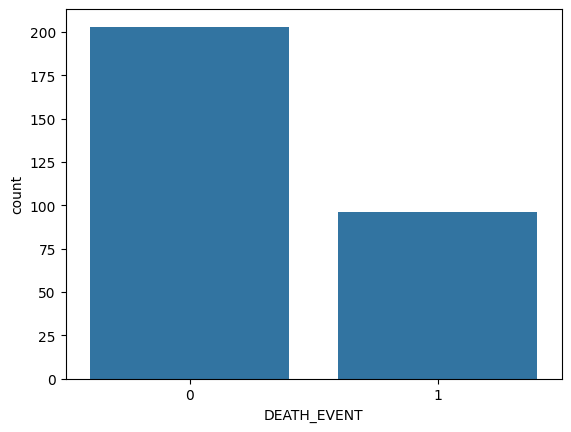

In [11]:
sns.countplot(x='DEATH_EVENT', data=df) #o= alive, 1=death

<Axes: xlabel='diabetes', ylabel='count'>

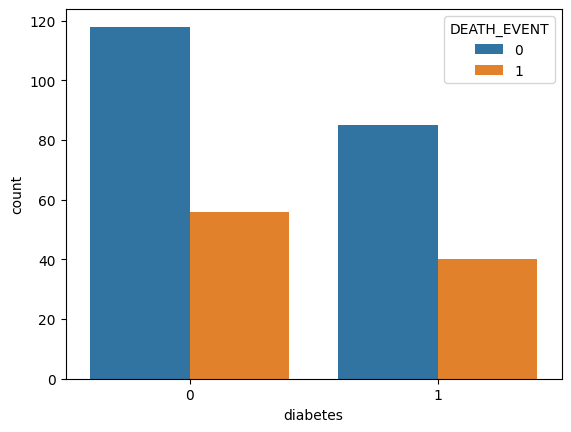

In [12]:
sns.countplot(x ='diabetes',hue='DEATH_EVENT',data=df)

<Axes: xlabel='high_blood_pressure', ylabel='count'>

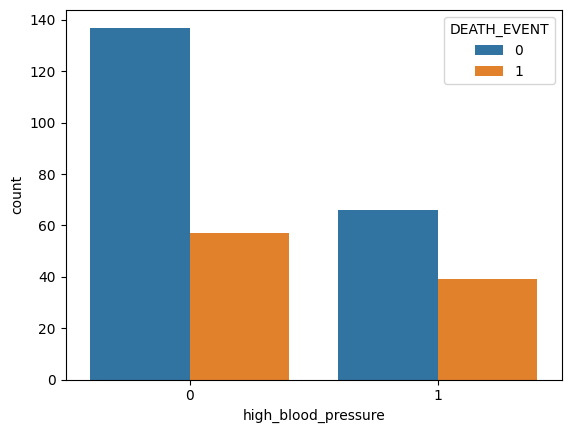

In [13]:
sns.countplot(x ='high_blood_pressure',hue='DEATH_EVENT',data=df)

In [14]:
df.corr()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
age,1.000000,0.088006,-0.081584,-0.101012,0.060098,0.093289,-0.052354,0.159187,-0.045966,0.065430,0.018668,-0.224068,0.253729
anaemia,0.088006,1.000000,-0.190741,-0.012729,0.031557,0.038182,-0.043786,0.052174,0.041882,-0.094769,-0.107290,-0.141414,0.066270
creatinine_phosphokinase,-0.081584,-0.190741,1.000000,-0.009639,-0.044080,-0.070590,0.024463,-0.016408,0.059550,0.079791,0.002421,-0.009346,0.062728
diabetes,-0.101012,-0.012729,-0.009639,1.000000,-0.004850,-0.012732,0.092193,-0.046975,-0.089551,-0.157730,-0.147173,0.033726,-0.001943
ejection_fraction,0.060098,0.031557,-0.044080,-0.004850,1.000000,0.024445,0.072177,-0.011302,0.175902,-0.148386,-0.067315,0.041729,-0.268603
high_blood_pressure,0.093289,0.038182,-0.070590,-0.012732,0.024445,1.000000,0.049963,-0.004935,0.037109,-0.104615,-0.055711,-0.196439,0.079351
platelets,-0.052354,-0.043786,0.024463,0.092193,0.072177,0.049963,1.000000,-0.041198,0.062125,-0.125120,0.028234,0.010514,-0.049139
serum_creatinine,0.159187,0.052174,-0.016408,-0.046975,-0.011302,-0.004935,-0.041198,1.000000,-0.189095,0.006970,-0.027414,-0.149315,0.294278
serum_sodium,-0.045966,0.041882,0.059550,-0.089551,0.175902,0.037109,0.062125,-0.189095,1.000000,-0.027566,0.004813,0.087640,-0.195204
sex,0.065430,-0.094769,0.079791,-0.157730,-0.148386,-0.104615,-0.125120,0.006970,-0.027566,1.000000,0.445892,-0.015608,-0.004316


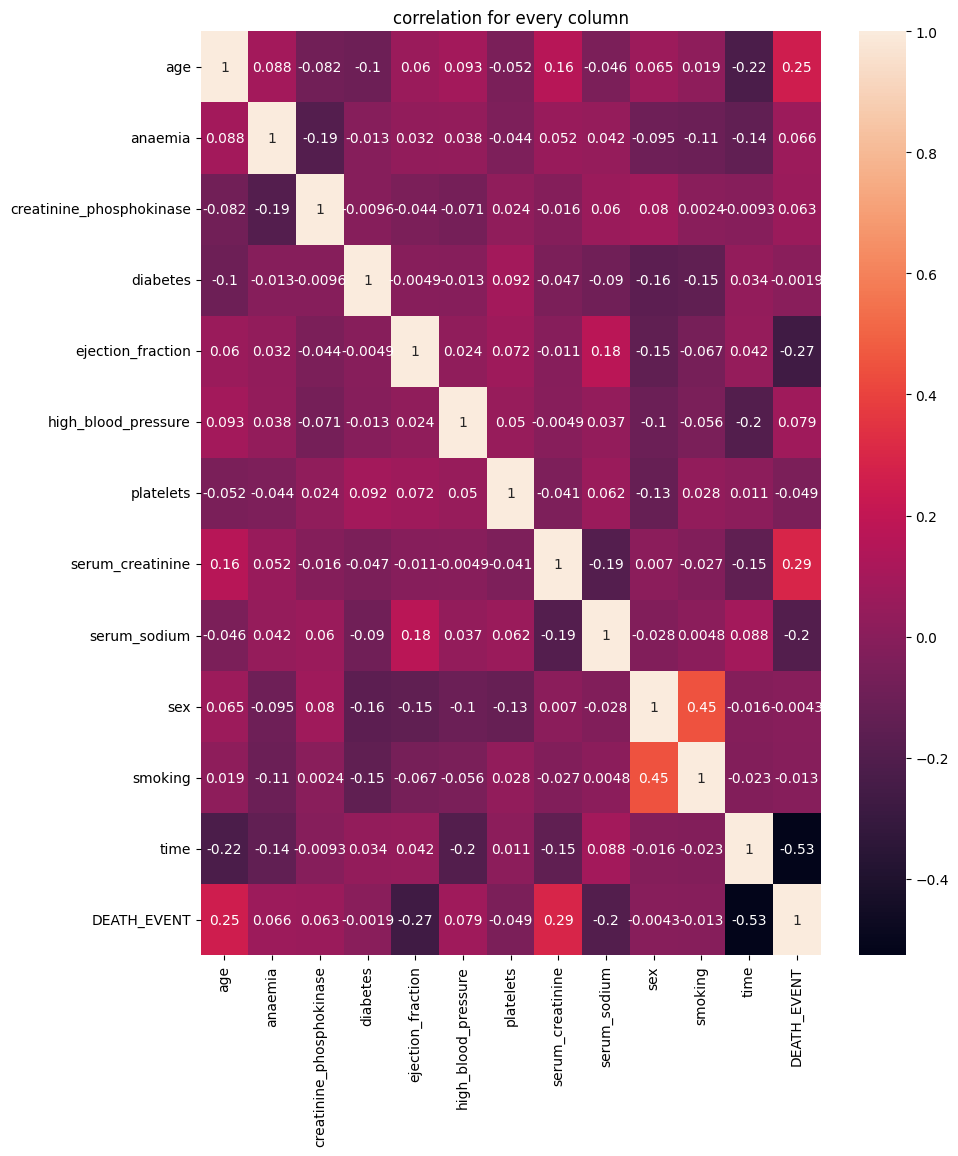

In [15]:
plt.figure(figsize = (10,12))
plt.title("correlation for every column")
sns.heatmap(df.corr(),annot=True)
plt.savefig("heatmap.png")

# ***Separate x,y***

In [16]:
x =df.drop("DEATH_EVENT",axis=1)

In [17]:
y = df[["DEATH_EVENT"]]

In [18]:
x.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8


In [19]:
y.head()

,DEATH_EVENT
0,1
1,1
2,1
3,1
4,1


# ***TrainSet & TestSet Separate***

In [20]:
xtrain,xtest,ytrain,ytest =tests(x,y,test_size =0.3,random_state=51)

In [21]:
xtrain.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time
284,50.0,1,54,0,40,0,279000.0,0.8,141,1,0,250
7,60.0,1,315,1,60,0,454000.0,1.1,131,1,1,10
264,61.0,0,582,1,38,0,147000.0,1.2,141,1,0,237
223,47.0,0,582,0,25,0,130000.0,0.8,134,1,0,201
126,46.0,0,168,1,17,1,271000.0,2.1,124,0,0,100


In [22]:
xtrain.shape

(209, 12)

In [23]:
xtest.shape

(90, 12)

In [24]:
dt = DecisionTreeClassifier()

In [25]:
dt.fit(xtrain,ytrain)

DecisionTreeClassifier()

[Text(0.4270833333333333, 0.9444444444444444, 'x[11] <= 73.5\ngini = 0.425\nsamples = 209\nvalue = [145, 64]'),
 Text(0.2013888888888889, 0.8333333333333334, 'x[11] <= 52.0\ngini = 0.282\nsamples = 47\nvalue = [8, 39]'),
 Text(0.3142361111111111, 0.8888888888888888, 'True  '),
 Text(0.125, 0.7222222222222222, 'x[2] <= 56.0\ngini = 0.188\nsamples = 38\nvalue = [4, 34]'),
 Text(0.05555555555555555, 0.6111111111111112, 'x[8] <= 134.5\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.027777777777777776, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.08333333333333333, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.19444444444444445, 0.6111111111111112, 'x[2] <= 2018.0\ngini = 0.153\nsamples = 36\nvalue = [3, 33]'),
 Text(0.1388888888888889, 0.5, 'x[3] <= 0.5\ngini = 0.111\nsamples = 34\nvalue = [2, 32]'),
 Text(0.1111111111111111, 0.3888888888888889, 'gini = 0.0\nsamples = 19\nvalue = [0, 19]'),
 Text(0.16666666666666666, 0.3888888888888889, 'x[2] <= 204.0\ngini = 0.2

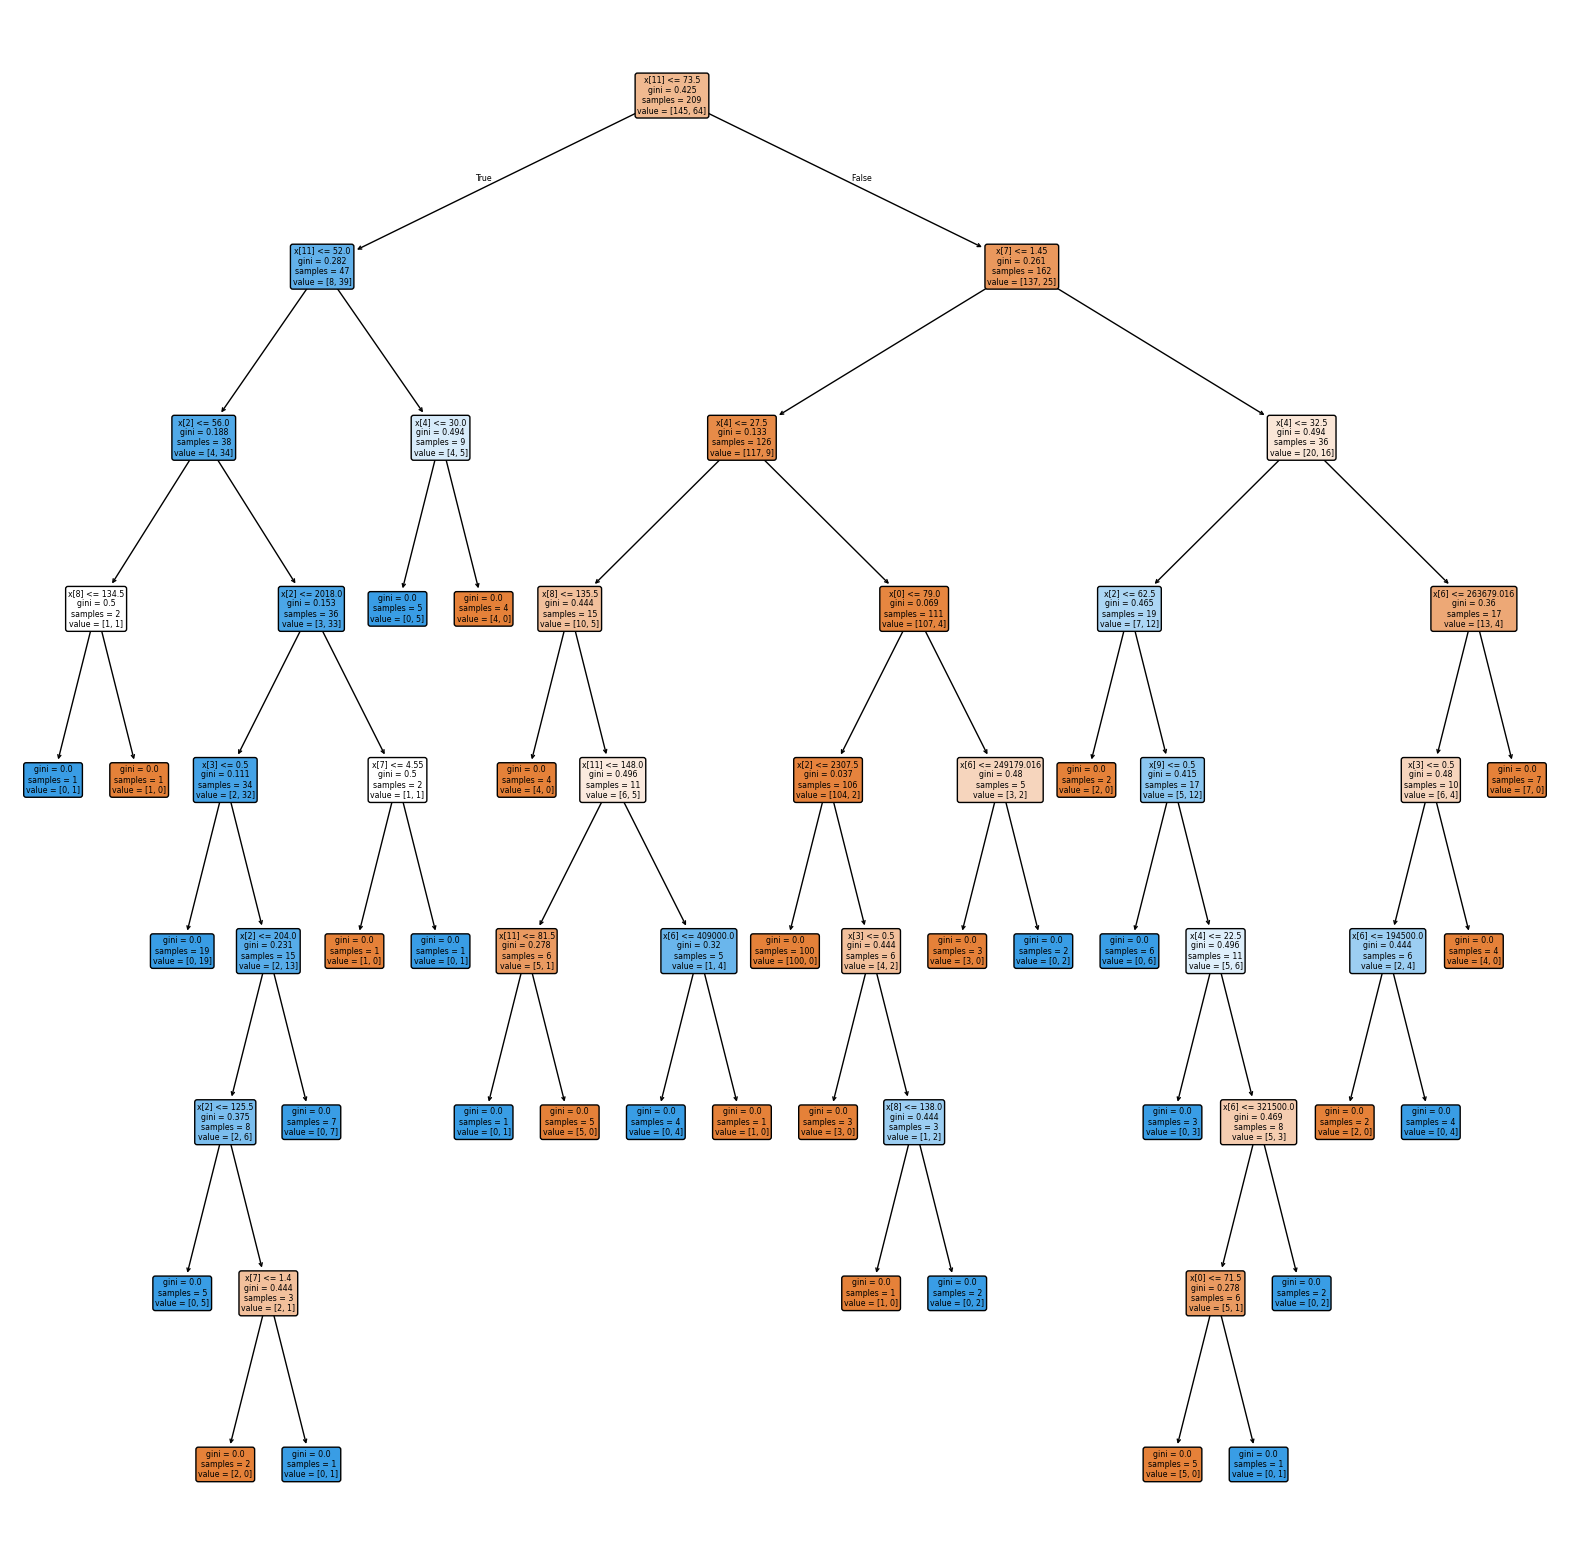

In [26]:
#to see the decisionTree
plt.figure(figsize=(20,20))
tree.plot_tree(dt,filled=True,rounded=True)

In [27]:
plt.savefig("decisionTree.png",dpi=1200)

<Figure size 640x480 with 0 Axes>

In [28]:
pred = dt.predict(xtest)
pred

array([0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0])

In [29]:
np.array(ytest)

array([[0],
       [1],
       [0],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [1],
       [0],
       [1],
       [0],
       [1],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [1],
       [0],
       [1],
       [1],
       [0],
       [1],
       [0],
       [1],
       [0],
       [1],
       [0],
       [1],
       [0],
       [1],
       [0],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [1],
       [0],
       [0],
       [0],
    

# ***ConfusionMatrix***

In [30]:
classification_report(ytest,pred)

'              precision    recall  f1-score   support\n\n           0       0.84      0.90      0.87        58\n           1       0.79      0.69      0.73        32\n\n    accuracy                           0.82        90\n   macro avg       0.81      0.79      0.80        90\nweighted avg       0.82      0.82      0.82        90\n'

In [31]:
print(classification_report(ytest,pred))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87        58
           1       0.79      0.69      0.73        32

    accuracy                           0.82        90
   macro avg       0.81      0.79      0.80        90
weighted avg       0.82      0.82      0.82        90



In [32]:
cm = confusion_matrix(ytest,pred)#[[tp,fn][fp,tn]]
cm

array([[52,  6],
       [10, 22]])

Text(0.5, 1.0, 'Confusion Matrix')

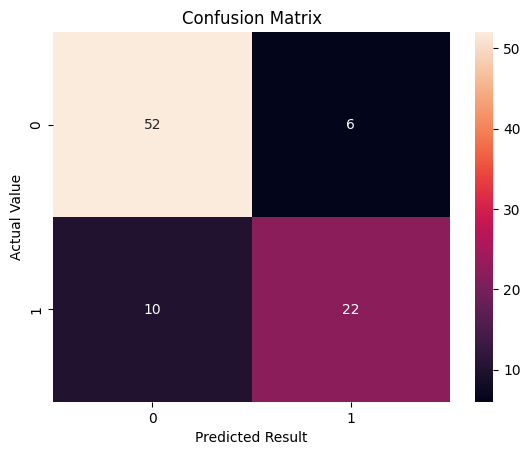

In [33]:
sns.heatmap(cm, annot=True)
plt.xlabel("Predicted Result")
plt.ylabel("Actual Value")
plt.title("Confusion Matrix")

In [34]:
plt.savefig("Heatmap2.png")

<Figure size 640x480 with 0 Axes>

In [35]:
tp,fn,fp,tn = confusion_matrix(ytest,pred).reshape(-1) #.reshape(-1) => to manage value error

In [36]:
tp

np.int64(52)

In [37]:
fn

np.int64(6)

In [38]:
accuracy=(tp+tn)/(tp+tn+fp+fn)

In [39]:
accuracy

np.float64(0.8222222222222222)

In [40]:
precision = tp/(tp+fp)
precision

np.float64(0.8387096774193549)

In [41]:
from sklearn.metrics import RocCurveDisplay as pc #roc / auc = precision curve

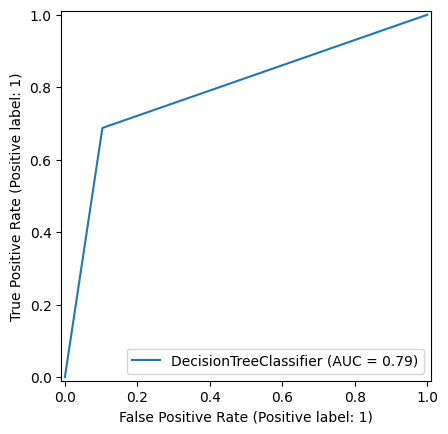

In [42]:
pc.from_estimator(dt, xtest, ytest)

In [43]:
accuracy_score(ytest,pred)

0.8222222222222222

In [44]:
dt.score(xtest, ytest)

0.8222222222222222

# ***random forest classifiear***

In [81]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=135,min_samples_split=3,max_depth= 11,max_features = 'log2',criterion= 'entropy')

In [82]:
rf.fit(xtrain,ytrain)

RandomForestClassifier(criterion='entropy', max_depth=11, max_features='log2',
                       min_samples_split=3, n_estimators=135)

In [84]:
rf.score(xtest,ytest)

0.8666666666666667

# ***Random Search CV***

In [85]:
from sklearn.model_selection import RandomizedSearchCV
tree = np.random.randint(15,150,30) #15 theke 150 er modde 30 ta tree genarate korbe

In [86]:
tree

array([ 20,  17, 135,  37,  37,  65,  43,  97,  46, 120, 144,  68,  16,
        47,  44,  95,  58,  37,  57,  22,  98,  38,  29, 102,  83, 109,
        50,  23,  15,  93])

In [87]:
max_features= ['sqrt','log2']
max_depth = np.random.randint(2,12,50)

In [88]:
max_features = ["sqrt", "log2"]
max_depth = np.random.randint(2, 12, 50)  # 50 random values between 2 and 11
criterion = ["gini", "entropy"]
min_samples_split = [2, 3, 4]

grid = {
    'n_estimators': tree,
    'criterion': criterion,
    'max_features': max_features,
    'max_depth': max_depth,
    'min_samples_split': min_samples_split
}

print(grid)

{'n_estimators': array([ 20,  17, 135,  37,  37,  65,  43,  97,  46, 120, 144,  68,  16,
        47,  44,  95,  58,  37,  57,  22,  98,  38,  29, 102,  83, 109,
        50,  23,  15,  93]), 'criterion': ['gini', 'entropy'], 'max_features': ['sqrt', 'log2'], 'max_depth': array([ 2,  9,  2,  8, 11,  7,  3,  8,  2, 10,  5, 10,  9,  7,  5,  5,  4,
        7,  2,  9,  5,  7,  8,  3,  2, 11,  7,  9,  3, 10,  4,  9,  3,  6,
        2,  8,  4,  3, 10,  8,  6,  5, 10,  8, 10,  7,  5,  3, 11,  4]), 'min_samples_split': [2, 3, 4]}


In [90]:
rcv = RandomizedSearchCV(rf,grid,n_iter= 100,cv =3)

In [91]:
rcv.fit(xtrain,ytrain)

RandomizedSearchCV(cv=3,
                   estimator=RandomForestClassifier(criterion='entropy',
                                                    max_depth=11,
                                                    max_features='log2',
                                                    min_samples_split=3,
                                                    n_estimators=135),
                   n_iter=100,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': array([ 2,  9,  2,  8, 11,  7,  3,  8,  2, 10,  5, 10,  9,  7,  5,  5,  4,
        7,  2,  9,  5,  7,  8,  3,  2, 11,  7,  9,  3, 10,  4,  9,  3,  6,
        2,  8,  4,  3, 10,  8,  6,  5, 10,  8, 10,  7,  5,  3, 11,  4]),
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_split': [2, 3, 4],
                                        'n_estimators': array([ 20,  17, 135,  37,  37,  65,  43,  97,  46, 120, 144,  68,  16,
        47,  44,  95,  58,  37,  57,  22,  98,  38,  29, 102,  83, 109,
        50,  23,  15,  93])})

In [92]:
rcv.cv_results_

{'mean_fit_time': array([0.03558358, 0.08440765, 0.13742892, 0.12910509, 0.06570347,
        0.14082162, 0.02381937, 0.09024541, 0.13202826, 0.03816477,
        0.06866503, 0.26332243, 0.04603322, 0.23028557, 0.11958639,
        0.0373083 , 0.0234011 , 0.06968013, 0.06266578, 0.06516679,
        0.06555223, 0.1164314 , 0.04283738, 0.16837716, 0.04156065,
        0.05238024, 0.06474185, 0.07701643, 0.08375025, 0.1322608 ,
        0.08608937, 0.05298837, 0.06008887, 0.0909578 , 0.09359129,
        0.1361719 , 0.20168384, 0.06477364, 0.06129781, 0.02499016,
        0.05022359, 0.09002074, 0.03446484, 0.13038111, 0.06548103,
        0.0252196 , 0.04668442, 0.03392323, 0.17017078, 0.0804104 ,
        0.1415441 , 0.14607716, 0.11062765, 0.22294029, 0.15620216,
        0.10593144, 0.04309265, 0.20954378, 0.03019333, 0.0343442 ,
        0.15902464, 0.10963488, 0.02607544, 0.054118  , 0.13999248,
        0.07747595, 0.08194558, 0.13581578, 0.09706028, 0.09225074,
        0.02448122, 0.13620504,

In [93]:
tuning_result = pd.DataFrame(rcv.cv_results_)
tuning_result

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_estimators,param_min_samples_split,param_max_features,param_max_depth,param_criterion,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,0.035584,0.002380,0.005174,0.000180,23,2,sqrt,5,entropy,"{'n_estimators': 23, 'min_samples_split': 2, '...",0.871429,0.771429,0.811594,0.818150,0.041087,88
1,0.084408,0.001287,0.008410,0.001058,58,2,log2,10,entropy,"{'n_estimators': 58, 'min_samples_split': 2, '...",0.871429,0.814286,0.811594,0.832436,0.027594,70
2,0.137429,0.002040,0.013125,0.004662,98,4,log2,6,gini,"{'n_estimators': 98, 'min_samples_split': 4, '...",0.900000,0.871429,0.811594,0.861008,0.036836,10
3,0.129105,0.000901,0.009571,0.000080,93,2,log2,9,gini,"{'n_estimators': 93, 'min_samples_split': 2, '...",0.885714,0.857143,0.811594,0.851484,0.030523,27
4,0.065703,0.001597,0.007201,0.000793,46,2,log2,5,gini,"{'n_estimators': 46, 'min_samples_split': 2, '...",0.871429,0.828571,0.869565,0.856522,0.019778,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.235372,0.051278,0.013028,0.002879,120,3,sqrt,3,entropy,"{'n_estimators': 120, 'min_samples_split': 3, ...",0.842857,0.842857,0.855072,0.846929,0.005758,33
96,0.062357,0.000903,0.006569,0.000205,43,2,sqrt,10,gini,"{'n_estimators': 43, 'min_samples_split': 2, '...",0.857143,0.885714,0.811594,0.851484,0.030523,27
97,0.026518,0.000149,0.004492,0.000071,17,2,sqrt,7,entropy,"{'n_estimators': 17, 'min_samples_split': 2, '...",0.842857,0.800000,0.811594,0.818150,0.018100,88
98,0.091948,0.006626,0.007554,0.000060,65,2,log2,2,entropy,"{'n_estimators': 65, 'min_samples_split': 2, '...",0.771429,0.785714,0.855072,0.804072,0.036531,95


In [94]:
rcv.best_score_

np.float64(0.8755003450655625)

In [95]:
rcv.best_params_

{'n_estimators': np.int64(58),
 'min_samples_split': 3,
 'max_features': 'sqrt',
 'max_depth': np.int64(7),
 'criterion': 'entropy'}

In [96]:
rcv.best_estimator_

RandomForestClassifier(criterion='entropy', max_depth=np.int64(7),
                       min_samples_split=3, n_estimators=np.int64(58))

In [97]:
rcv2 = rcv.best_estimator_
rcv2.fit(xtrain, ytrain)
rcv2.score(xtest, ytest)

0.8777777777777778